# 🎯 Telco Churn: Baseline Model Training

**Objective**: Train initial XGBoost baseline model for customer churn prediction

**Strategy**:
- Load and validate raw telco customer data
- Build preprocessing pipeline (scaling, encoding, imputation)
- Train XGBoost classifier with class imbalance handling
- Evaluate using stratified 5-fold cross-validation
- Optimize threshold for maximum recall (churn detection priority)
- Save model artifacts for serving and hyperparameter tuning

**Business Context**:
- Telecom company losing customers to competitors
- Early churn detection enables proactive retention
- Recall prioritized over precision (cost of missing churner > false alarm)

---
*Run from project root with activated mlops_env*

## 1. Setup & Imports

In [5]:
# === 1. Setup & Imports ===
import pandas as pd
import numpy as np
import xgboost as xgb
import mlflow
import mlflow.xgboost
import json
from pathlib import Path
import sys
import warnings
from datetime import datetime
import joblib

# Sklearn imports
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    recall_score, 
    precision_score, 
    f1_score, 
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Project imports
project_root = Path.cwd().parent.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.config import settings
from src.features import fit_preprocessing_pipeline, transform_data, save_preprocessing_artifacts
from src.data import validate_data_quality

# Styling
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
warnings.filterwarnings('ignore')

# Random state for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print(f"✅ Environment ready | XGBoost: {xgb.__version__} | MLflow: {mlflow.__version__}")

✅ Environment ready | XGBoost: 3.2.0 | MLflow: 3.10.1


## 2. Configure MLflow Tracking

In [6]:
# === 2. Configure MLflow ===
mlflow.set_tracking_uri(settings.mlflow_tracking_uri)
mlflow.set_experiment(settings.mlflow_experiment_name)

print(f"🔗 MLflow Tracking URI: {settings.mlflow_tracking_uri}")
print(f"📊 Experiment: {settings.mlflow_experiment_name}")
print(f"📁 Artifacts Path: {settings.artifacts_path}")

2026/04/06 07:41:52 INFO mlflow.tracking.fluent: Experiment with name 'telco_churn_baseline' does not exist. Creating a new experiment.


🔗 MLflow Tracking URI: http://localhost:5000
📊 Experiment: telco_churn_baseline
📁 Artifacts Path: artifacts


## 3. Load & Explore Data

In [7]:
# === 3. Load Data ===
data_paths = [
    Path('..', '..', 'data', 'raw', 'telco.csv'),
    Path('..', 'data', 'raw', 'telco.csv'),
    Path('data', 'raw', 'telco.csv'),
    Path('telco.csv')
]

data_file = next((p for p in data_paths if p.exists()), None)
if data_file is None:
    raise FileNotFoundError("telco.csv not found. Please place in data/raw/")

print(f"📁 Loading data from: {data_file}")
df = pd.read_csv(data_file)
print(f"✅ Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")

# Display basic info
print(f"\n📊 Data Overview:")
print(f"   Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"   Duplicate rows: {df.duplicated().sum()}")
print(f"   Missing values: {df.isnull().sum().sum()}")

📁 Loading data from: ..\..\data\raw\telco.csv
✅ Loaded: 7,043 rows × 50 columns

📊 Data Overview:
   Memory usage: 11.92 MB
   Duplicate rows: 0
   Missing values: 15751


In [8]:
# === 3.1 Data Quality Validation ===
quality_report = validate_data_quality(df)

print(f"\n📋 Data Quality Report:")
print(f"   Quality Score: {quality_report['quality_score']:.1f}/100")
print(f"   Missing Percentage: {quality_report['missing_percentage']:.2f}%")
print(f"   Duplicate Percentage: {quality_report['duplicate_percentage']:.2f}%")

if quality_report['quality_score'] < 80:
    print(f"\n⚠️  Warning: Low data quality score. Review data before proceeding.")


📋 Data Quality Report:
   Quality Score: 95.5/100
   Missing Percentage: 4.47%
   Duplicate Percentage: 0.00%



🎯 Target Variable: Churn Label

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

Churn Rate: 26.54%


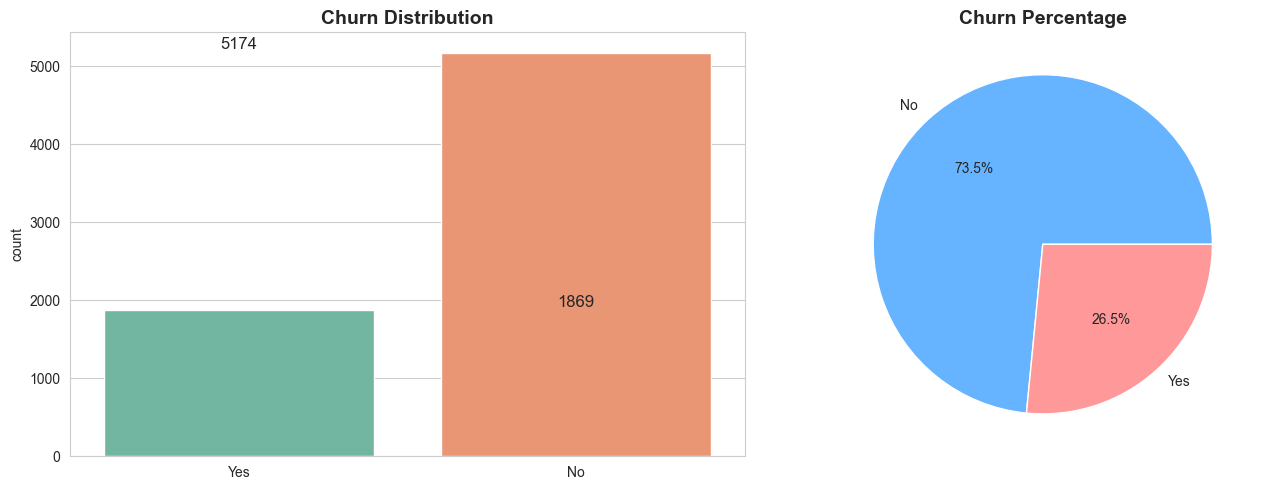

In [9]:
# === 3.2 Target Variable Analysis ===
target_col = 'Churn Label'

print(f"\n🎯 Target Variable: {target_col}")
print(f"\n{df[target_col].value_counts()}")
print(f"\nChurn Rate: {(df[target_col] == 'Yes').mean():.2%}")

# Visualize target distribution
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
sns.countplot(data=df, x=target_col, ax=ax[0], palette='Set2')
ax[0].set_title('Churn Distribution', fontsize=14, fontweight='bold')
ax[0].set_xlabel('')
for i, v in enumerate(df[target_col].value_counts().values):
    ax[0].text(i, v + 50, str(v), ha='center', fontsize=12)

# Pie chart
df[target_col].value_counts().plot.pie(ax=ax[1], autopct='%1.1f%%', colors=['#66b3ff', '#ff9999'])
ax[1].set_title('Churn Percentage', fontsize=14, fontweight='bold')
ax[1].set_ylabel('')

plt.tight_layout()

plt.show()



## 4. Preprocessing Pipeline

In [10]:
# === 4. Preprocessing Pipeline ===
print("\n🔄 Building Preprocessing Pipeline...")
print("=" * 60)

# Define features to exclude
EXCLUDE_COLS = [
    'Customer ID', 'Country', 'State', 'City', 'Zip Code',
    'Latitude', 'Longitude', 'Churn Label', 'Customer Status',
    'Churn Score', 'CLTV', 'Churn Category', 'Churn Reason',
    'Total Revenue', 'Total Refunds', 'Quarter'
]

# Separate features and target
feature_cols = [c for c in df.columns if c not in EXCLUDE_COLS]
X_df = df[feature_cols].copy()
y_df = df[target_col].map({'Yes': 1, 'No': 0}).fillna(0).astype(int)

print(f"✅ Features: {X_df.shape[1]}")
print(f"✅ Target distribution: {y_df.value_counts().to_dict()}")

# Fit preprocessing pipeline
pipeline, feature_names, metadata = fit_preprocessing_pipeline(
    df, 
    target_col=target_col,
    validate=True
)

# Transform data
y = y_df
X, _ = transform_data(df, pipeline, metadata, validate=False)

print(f"\n✅ Preprocessed: {X.shape[0]:,} samples × {X.shape[1]} features")
print(f"🔍 Missing values after preprocessing: {X.isnull().sum().sum()}")


🔄 Building Preprocessing Pipeline...
✅ Features: 34
✅ Target distribution: {0: 5174, 1: 1869}
   Standardized columns: ['customer_id', 'gender', 'age', 'under_30', 'senior_citizen']...
   Numeric features: 9
   Categorical features: 3
   Total features after encoding: 39
   Fitting pipeline...
   ✅ Pipeline fitted successfully

✅ Preprocessed: 7,043 samples × 39 features
🔍 Missing values after preprocessing: 0


In [11]:
# === 4.1 Save Preprocessing Artifacts ===
artifacts_dir = Path('..', '..', 'artifacts')
artifacts_dir.mkdir(parents=True, exist_ok=True)

save_preprocessing_artifacts(pipeline, metadata, artifacts_dir)

print(f"\n💾 Preprocessing artifacts saved to: {artifacts_dir}")
print(f"   - preprocessing_pipeline.joblib")
print(f"   - preprocessing_metadata.json")


💾 Preprocessing artifacts saved to: ..\..\artifacts
   - preprocessing_pipeline.joblib
   - preprocessing_metadata.json


## 5. Model Training with Cross-Validation

In [12]:
# === 5. Model Training ===
print("\n🚀 Training Baseline XGBoost Model...")
print("=" * 60)

# Configure cross-validation
CV_FOLDS = 5
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

# Handle class imbalance
n_neg = np.sum(y == 0)
n_pos = np.sum(y == 1)
scale_pos_weight = n_neg / n_pos if n_pos > 0 else 1.0

print(f"📊 Class Distribution:")


print(f"   - Scale Pos Weight: {scale_pos_weight:.2f}")

# XGBoost baseline parameters
model_params = {
    'max_depth': 4,
    'learning_rate': 0.1,
    'n_estimators': 200,
    'objective': 'binary:logistic',
    'scale_pos_weight': scale_pos_weight,
    'random_state': RANDOM_STATE,
    'n_jobs': -1,
    'early_stopping_rounds': 20  # ✅ XGBoost 3.2.0: Constructor parameter
}

print(f"\n📋 Model Parameters:")
for k, v in model_params.items():
    print(f"   - {k}: {v}")


🚀 Training Baseline XGBoost Model...
📊 Class Distribution:
   - Scale Pos Weight: 2.77

📋 Model Parameters:
   - max_depth: 4
   - learning_rate: 0.1
   - n_estimators: 200
   - objective: binary:logistic
   - scale_pos_weight: 2.7683253076511503
   - random_state: 42
   - n_jobs: -1
   - early_stopping_rounds: 20


In [13]:
# === 5.1 Cross-Validation Training ===


cv_results = {
    'recall': [], 
    'precision': [], 
    'f1': [], 
    'auc': [], 
    'threshold': []
}

# End any previous run
mlflow.end_run()

with mlflow.start_run(run_name="xgboost_baseline") as run:
    # Log parameters
    mlflow.log_params(model_params)
    mlflow.log_param("cv_folds", CV_FOLDS)
    
    for fold, (train_idx, val_idx) in enumerate(cv.split(X, y), 1):
        print(f"\n  Fold {fold}/{CV_FOLDS}")
        
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]  # ✅ Use numpy indexing for y
        
        # Train model
        model = xgb.XGBClassifier(**model_params)
        model.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            verbose=False
        )
        
        # Predict probabilities
        y_val_pred_proba = model.predict_proba(X_val)[:, 1]
        
        # Find optimal threshold for max recall
        thresholds = np.arange(0.1, 0.9, 0.05)
        best_recall, best_threshold = 0, 0.5
        
        for thresh in thresholds:
            y_val_pred = (y_val_pred_proba >= thresh).astype(int)
            recall = recall_score(y_val, y_val_pred, zero_division=0)
            if recall > best_recall:
                best_recall, best_threshold = recall, thresh
        
        # Calculate metrics at optimal threshold
        y_val_pred_opt = (y_val_pred_proba >= best_threshold).astype(int)
        
        fold_metrics = {
            'recall': recall_score(y_val, y_val_pred_opt, zero_division=0),
            'precision': precision_score(y_val, y_val_pred_opt, zero_division=0),
            'f1': f1_score(y_val, y_val_pred_opt, zero_division=0),
            'auc': roc_auc_score(y_val, y_val_pred_proba),
            'threshold': best_threshold
        }
        
        for metric, value in fold_metrics.items():
            cv_results[metric].append(value)
            print(f"    - {metric}: {value:.3f}")
        
        # Log fold metrics
        mlflow.log_metrics({f"fold_{fold}_{k}": v for k, v in fold_metrics.items()})


  Fold 1/5
    - recall: 0.976
    - precision: 0.436
    - f1: 0.602
    - auc: 0.910
    - threshold: 0.100

  Fold 2/5
    - recall: 0.968
    - precision: 0.413
    - f1: 0.579
    - auc: 0.901
    - threshold: 0.100

  Fold 3/5
    - recall: 0.981
    - precision: 0.414
    - f1: 0.583
    - auc: 0.906
    - threshold: 0.100

  Fold 4/5
    - recall: 0.981
    - precision: 0.438
    - f1: 0.606
    - auc: 0.912
    - threshold: 0.100

  Fold 5/5
    - recall: 0.968
    - precision: 0.457
    - f1: 0.621
    - auc: 0.917
    - threshold: 0.100
🏃 View run xgboost_baseline at: http://localhost:5000/#/experiments/1/runs/fcb59703ef1a42929688fc99f348b879
🧪 View experiment at: http://localhost:5000/#/experiments/1



📈 Cross-Validation Results (mean ± std):
   - recall: 0.975 ± 0.006
   - precision: 0.432 ± 0.016
   - f1: 0.598 ± 0.015
   - auc: 0.909 ± 0.006
   - threshold: 0.100 ± 0.000


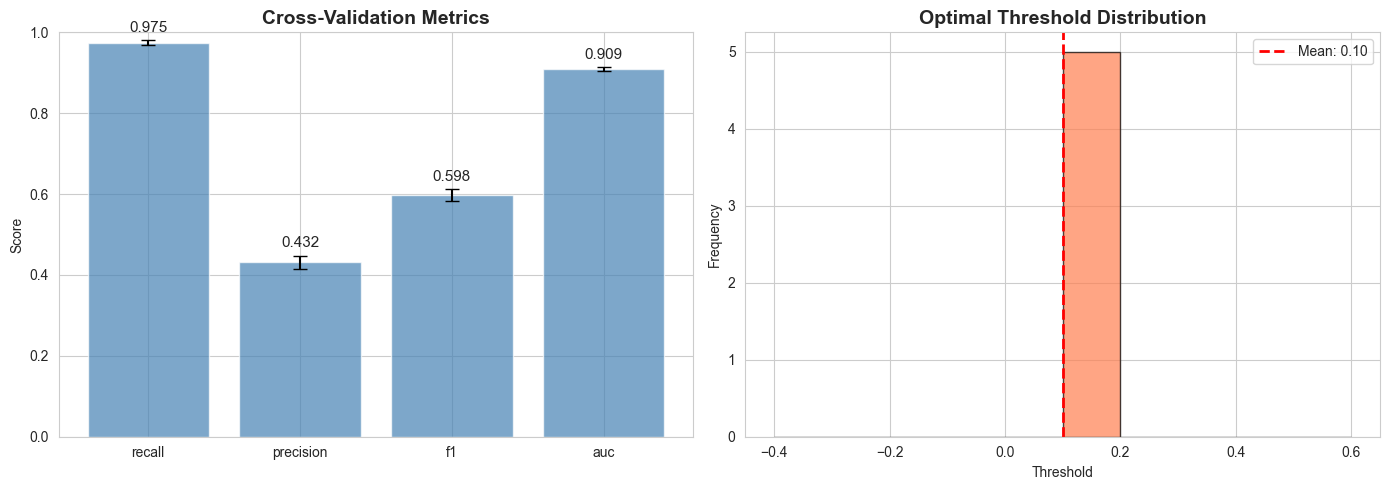

In [14]:
# === 5.2 Aggregate Results ===
avg_metrics = {k: np.mean(v) for k, v in cv_results.items()}
std_metrics = {k: np.std(v) for k, v in cv_results.items()}

print(f"\n📈 Cross-Validation Results (mean ± std):")
for k in ['recall', 'precision', 'f1', 'auc', 'threshold']:
    print(f"   - {k}: {avg_metrics[k]:.3f} ± {std_metrics[k]:.3f}")
    mlflow.log_metric(f"cv_{k}_mean", avg_metrics[k])
    mlflow.log_metric(f"cv_{k}_std", std_metrics[k])

# Visualize CV results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Metrics bar plot
metrics_to_plot = ['recall', 'precision', 'f1', 'auc']
means = [avg_metrics[m] for m in metrics_to_plot]
stds = [std_metrics[m] for m in metrics_to_plot]

axes[0].bar(metrics_to_plot, means, yerr=stds, capsize=5, color='steelblue', alpha=0.7)
axes[0].set_title('Cross-Validation Metrics', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1)
for i, (m, s) in enumerate(zip(means, stds)):
    axes[0].text(i, m + s + 0.02, f'{m:.3f}', ha='center', fontsize=11)

# Threshold distribution
axes[1].hist(cv_results['threshold'], bins=10, color='coral', alpha=0.7, edgecolor='black')
axes[1].axvline(avg_metrics['threshold'], color='red', linestyle='--', linewidth=2, label=f'Mean: {avg_metrics["threshold"]:.2f}')
axes[1].set_title('Optimal Threshold Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.savefig(artifacts_dir / 'cv_results.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Final Model Training


🎯 Training Final Model on Full Dataset...
✅ Final model trained on 7,043 samples
📊 Feature count: 39

📊 Top 10 Feature Importances:
                   feature  importance
                  contract    0.316725
                dependents    0.081318
       number_of_referrals    0.067627
payment_method_Credit Card    0.059978
          streaming_movies    0.049626
                   married    0.034926
              streaming_tv    0.026255
          tenure_in_months    0.025766
            monthly_charge    0.023461
           online_security    0.023262


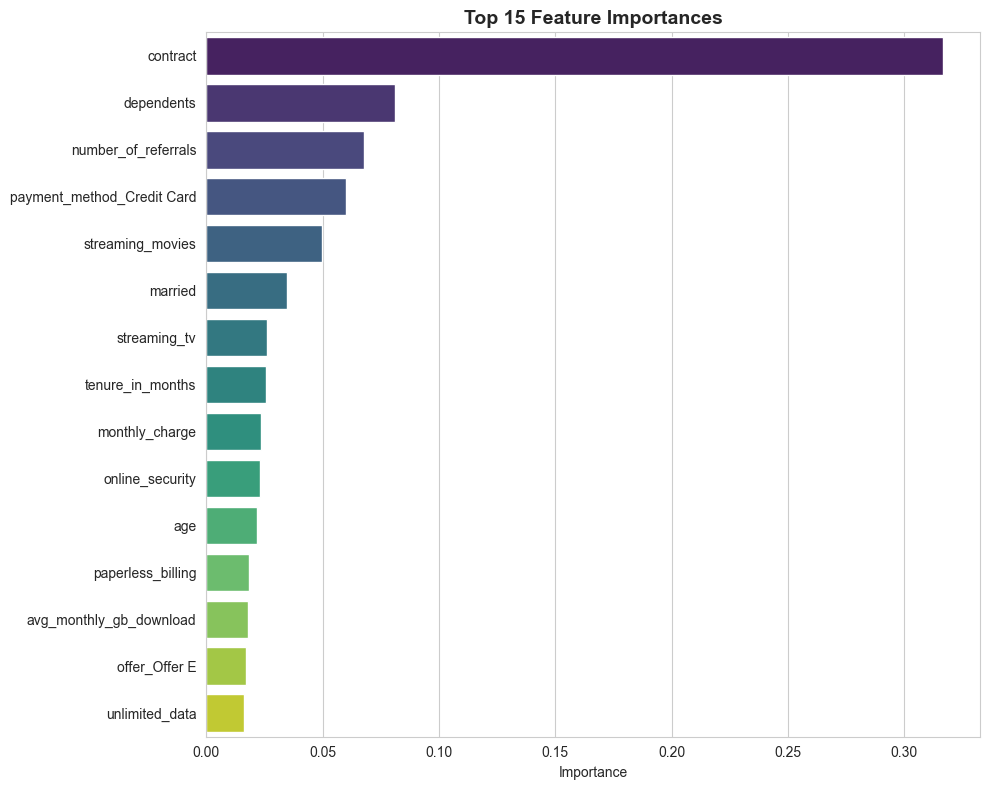

In [15]:
# === 6. Train Final Model ===
print(f"\n🎯 Training Final Model on Full Dataset...")

# Remove early_stopping_rounds for final training (no validation set)
final_params = {k: v for k, v in model_params.items() if k != 'early_stopping_rounds'}

final_model = xgb.XGBClassifier(**final_params)
final_model.fit(X, y, verbose=False)

print(f"✅ Final model trained on {X.shape[0]:,} samples")
print(f"📊 Feature count: {X.shape[1]}")

# Feature importance
if hasattr(final_model, 'feature_importances_'):
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': final_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print(f"\n📊 Top 10 Feature Importances:")
    print(importance_df.head(10).to_string(index=False))
    
    # Plot feature importance
    plt.figure(figsize=(10, 8))
    sns.barplot(data=importance_df.head(15), x='importance', y='feature', palette='viridis')
    plt.title('Top 15 Feature Importances', fontsize=14, fontweight='bold')
    plt.xlabel('Importance')
    plt.ylabel('')
    plt.tight_layout()
    plt.savefig(artifacts_dir / 'feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()

## 7. Save Artifacts for Serving

In [16]:
# === 7. Save Artifacts ===
print(f"\n💾 Saving Artifacts for Serving...")
print("=" * 60)

# 1. Save model as .pkl (for API)
joblib.dump(final_model, artifacts_dir / 'model.pkl')
print(f"✅ model.pkl saved")

# 2. Save serving config
serving_config = {
    'optimal_threshold': float(avg_metrics['threshold']),
    'feature_names': feature_names,
    'model_version': '1.0.0-baseline',
    'cv_recall': f"{avg_metrics['recall']:.3f} ± {std_metrics['recall']:.3f}",
    'cv_precision': f"{avg_metrics['precision']:.3f} ± {std_metrics['precision']:.3f}",
    'cv_auc': f"{avg_metrics['auc']:.3f} ± {std_metrics['auc']:.3f}",
    'created_at': datetime.now().isoformat(),
    'training_samples': len(X),
    'feature_count': len(feature_names)
}

with open(artifacts_dir / 'serving_config.json', 'w') as f:
    json.dump(serving_config, f, indent=2)
print(f"✅ serving_config.json saved")

# 3. Save training summary (for tuning notebook)
training_summary = {
    'cv_recall': f"{avg_metrics['recall']:.3f} ± {std_metrics['recall']:.3f}",
    'cv_precision': f"{avg_metrics['precision']:.3f} ± {std_metrics['precision']:.3f}",
    'cv_f1': f"{avg_metrics['f1']:.3f} ± {std_metrics['f1']:.3f}",
    'cv_auc': f"{avg_metrics['auc']:.3f} ± {std_metrics['auc']:.3f}",
    'best_threshold': float(avg_metrics['threshold']),
    'feature_count': len(feature_names),
    'churn_rate': float(y.mean()),
    'generated_at': datetime.now().isoformat()
}

with open(artifacts_dir / 'training_summary.json', 'w') as f:
    json.dump(training_summary, f, indent=2)
print(f"✅ training_summary.json saved")

# 4. Log model to MLflow
from mlflow.models.signature import infer_signature
signature = infer_signature(X.head(1), final_model.predict_proba(X.head(1))[:, 1])

mlflow.xgboost.log_model(
    final_model,
    artifact_path="model",
    signature=signature,
    registered_model_name=settings.model_registry_name
)
print(f"✅ Model logged to MLflow Registry: {settings.model_registry_name}")

print(f"\n📁 All artifacts saved to: {artifacts_dir.absolute()}")

2026/04/06 07:42:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



💾 Saving Artifacts for Serving...
✅ model.pkl saved
✅ serving_config.json saved
✅ training_summary.json saved


Successfully registered model 'telco_churn_model'.
2026/04/06 07:42:14 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: telco_churn_model, version 1


✅ Model logged to MLflow Registry: telco_churn_model

📁 All artifacts saved to: c:\Users\user\Desktop\Library\Work\Journey to Agentic_AI MLOps\Files\E2E project\Project churn\churn-scratch\Telco-churn\notebooks\experiments\..\..\artifacts


Created version '1' of model 'telco_churn_model'.


## 8. Summary & Next Steps

In [17]:
# === 8. Summary ===
print("\n" + "=" * 60)
print("📋 BASELINE TRAINING SUMMARY")
print("=" * 60)

print(f"""
Model: XGBoost Classifier
Training Samples: {len(X):,}
Features: {len(feature_names)}
Cross-Validation: {CV_FOLDS}-fold Stratified

Performance:
   - Recall: {avg_metrics['recall']:.3f} ± {std_metrics['recall']:.3f}
   - Precision: {avg_metrics['precision']:.3f} ± {std_metrics['precision']:.3f}
   - F1 Score: {avg_metrics['f1']:.3f} ± {std_metrics['f1']:.3f}
   - AUC-ROC: {avg_metrics['auc']:.3f} ± {std_metrics['auc']:.3f}
   - Optimal Threshold: {avg_metrics['threshold']:.2f}

Artifacts Saved:
   - preprocessing_pipeline.joblib
   - preprocessing_metadata.json
   - model.pkl
   - serving_config.json
   - training_summary.json
""")

print("\n✅ Baseline training complete!")
print("🚀 Next: Run hyperparameter_tuning.ipynb for optimization")
print(f"🔗 MLflow Run: {run.info.run_id}")


📋 BASELINE TRAINING SUMMARY

Model: XGBoost Classifier
Training Samples: 7,043
Features: 39
Cross-Validation: 5-fold Stratified

Performance:
   - Recall: 0.975 ± 0.006
   - Precision: 0.432 ± 0.016
   - F1 Score: 0.598 ± 0.015
   - AUC-ROC: 0.909 ± 0.006
   - Optimal Threshold: 0.10

Artifacts Saved:
   - preprocessing_pipeline.joblib
   - preprocessing_metadata.json
   - model.pkl
   - serving_config.json
   - training_summary.json


✅ Baseline training complete!
🚀 Next: Run hyperparameter_tuning.ipynb for optimization
🔗 MLflow Run: fcb59703ef1a42929688fc99f348b879


## ✅ Next Steps

1. Review MLflow UI: http://localhost:5000
2. Run `hyperparameter_tuning.ipynb` to optimize hyperparameters
3. Test API locally with saved model
4. Deploy to staging for A/B testing

---
*Notebook for Telco Churn MLOps Project*